# DT-letter-shaped flat-top beam shaping at a finite distance

This notebook designs a **phase-only flat-optics element** that reshapes a Gaussian input beam into a DT-letter-shaped flat-top intensity distribution at a finite propagation distance. The phase is learned with a near-field PINN that solves the Monge--Ampère beam-shaping equation and is then validated with angular-spectrum propagation.

The workflow is:

1. define the Gaussian source and DT-letter target in the physical target plane,
2. train or load the near-field PINN phase profile,
3. visualize the learned phase mask,
4. propagate the phase-modulated field to the target plane with wave optics


## Imports and numerical backend

The notebook uses **PyTorch** for the PINN and automatic differentiation, the local `pinn_shaper` package for the near-field Monge--Ampère solver, and standard plotting and interpolation utilities. If a CUDA GPU is available, PyTorch tensors are placed on the GPU by default.


In [4]:
# Import the necessary modules.
import torch

if torch.cuda.is_available():
    torch.set_default_device("cuda")

import matplotlib.pyplot as plt
import numpy as np
import pinn_shaper

from pinn_shaper import Nearfield_PINN
from pinn_shaper import um, mm, cm
from pinn_shaper import load_image, create_interpolator
from scipy.ndimage import gaussian_filter as scipy_gaussian_filter

## Problem setup: Gaussian source and DT-letter target

The input beam is a Gaussian irradiance profile,

$$
I(x,y)=\exp\!\left[-2\left(\frac{\sqrt{x^2+y^2}}{w_I}\right)^2\right],
$$

sampled on a square source aperture of side `extent_source`. The desired output is a smoothed DT-letter-shaped flat-top image in a target plane of side `extent_target`, located a distance $z$ downstream.

For the finite-distance formulation, the normalized phase defines the ray map

$$
\bar t_x=\bar x+\frac{\bar\Phi_{\bar x}}{\bar K},
\qquad
\bar t_y=\bar y+\frac{\bar\Phi_{\bar y}}{\bar K},
$$

with

$$
\bar K=\sqrt{1-s^2(\bar\Phi_{\bar x}^2+\bar\Phi_{\bar y}^2)},
\qquad s=\frac{M}{z}.
$$

The PINN used here is a fully connected network with 4 hidden layers and 150 neurons per layer. The wave-optics validation uses the same output-plane scaling as the original DT-letter setup.


In [5]:
extent_source = 6 * mm
extent_target = 10 * mm

w_I = 1000 * um

def I_fun(x, y):
    # Gaussian source irradiance with beam waist w_I.
    r = torch.sqrt(x**2 + y**2)
    return torch.exp(-(r / w_I)**2)**2


# Smoothed DT-letter-shaped flat-top target.
image = np.array(scipy_gaussian_filter(load_image("images/DT.png"),10,mode="nearest",cval=0,),dtype="float32")

E_fun = create_interpolator(
    torch.tensor(image),mode="bilinear",region=[-extent_target / 2,extent_target / 2,-extent_target / 2,extent_target / 2,],align_corners=True)

λ = 1.0 * um
z = 10 * cm

# Preserve the enlarged output window used by the original DT-letter notebook.
target_plane_scale_factor = 2.0

# Initialize the near-field PINN solver.
solver = Nearfield_PINN(
    I_fun,E_fun,extent_source,extent_target,
    z,λ,integration_points=5000,hidden_layers=4,
    num_features=150,constrain=False,symmetry=None)


## Inspect the normalized source and target

These plots check the two distributions used by the PDE residual: the Gaussian source irradiance at the phase mask and the prescribed DT-letter-shaped target irradiance in the output plane.


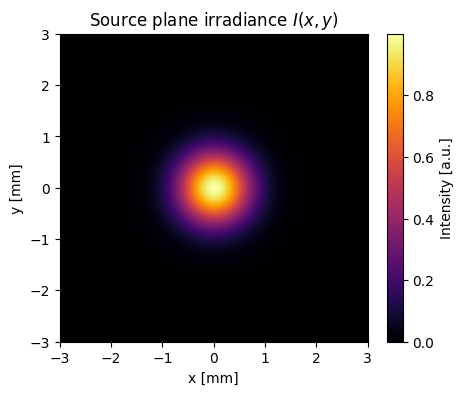

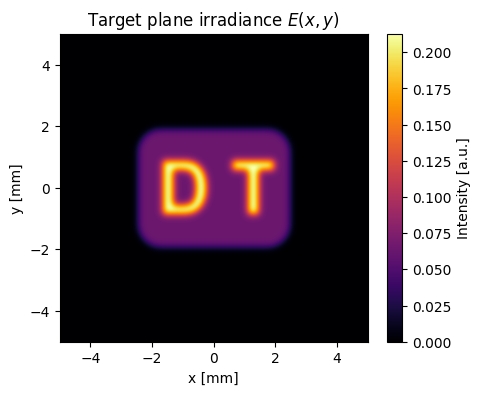

In [6]:
solver.plot_source_irradiance()
solver.plot_target_irradiance()

## PINN training schedule

The phase network is optimized in stages. Adam first gives a robust initial decrease of the residual, and L-BFGS then refines the phase using larger collocation sets. The loss combines the Monge--Ampère residual with additional constraints weighted by `loss_weights`.

The notebook also reports test losses on separately sampled interior and boundary points to monitor whether the trained phase satisfies the PDE away from the training batch.


In [7]:
# Define common parameters for test loss and noise.
residual_power = 1.5
loss_weights = [100.0, 1, 1]
noise_amplitude = 0.0
add_noise = False
effective_noise = noise_amplitude if add_noise else 0.0
num_test_interior = 1000
num_test_boundary = 200

print("Run Phase 1: Adam")
solver.run_phase(
    optimizer_type="adam",
    iterations=1000,
    num_domain=1000,
    num_boundary=100,
    residual_power=residual_power,
    loss_weights=loss_weights,
    effective_noise=effective_noise,
    num_test_interior=num_test_interior,
    num_test_boundary=num_test_boundary,
    lr=0.001,
)

print("Run Phase 2: Adam")
solver.run_phase(
    optimizer_type="adam",
    iterations=2000,
    num_domain=1500 * 10,
    num_boundary=100 * 10,
    residual_power=residual_power,
    loss_weights=loss_weights,
    effective_noise=effective_noise,
    num_test_interior=num_test_interior,
    num_test_boundary=num_test_boundary,
    lr=0.0001,
)

print("Run Phase 3: L-BFGS")
solver.run_phase(
    optimizer_type="lbfgs",
    num_domain=1500 * 15,
    num_boundary=100 * 15,
    residual_power=residual_power,
    loss_weights=loss_weights,
    effective_noise=0.001,
    num_test_interior=num_test_interior,
    num_test_boundary=num_test_boundary,
    max_iterations_lbfgs=4000,
    lr_lbfgs=1,
)

print("Run Phase 4: L-BFGS")
solver.run_phase(
    optimizer_type="lbfgs",
    num_domain=1500 * 15,
    num_boundary=100 * 15,
    residual_power=residual_power,
    loss_weights=loss_weights,
    effective_noise=0.0,
    num_test_interior=num_test_interior,
    num_test_boundary=num_test_boundary,
    max_iterations_lbfgs=1000,
    lr_lbfgs=1,
)

solver.print_final_test_loss(
    num_test_interior,
    num_test_boundary,
    residual_power,
    loss_weights,
    effective_noise,
)


Run Phase 1: Adam
Adam Iter     0: Loss = 2.80800581 (Interior = 0.02808006, BC_x = 0.00000000, BC_y = 0.00000000)
           Test Loss = 2.79905748 (Interior = 0.02799058, BC_x = 0.00000000, BC_y = 0.00000000)
Adam Iter   100: Loss = 1.23911250 (Interior = 0.01239112, BC_x = 0.00000000, BC_y = 0.00000000)
           Test Loss = 1.22963107 (Interior = 0.01229631, BC_x = 0.00000000, BC_y = 0.00000000)
Adam Iter   200: Loss = 0.24192001 (Interior = 0.00241920, BC_x = 0.00000000, BC_y = 0.00000000)
           Test Loss = 0.23626885 (Interior = 0.00236269, BC_x = 0.00000000, BC_y = 0.00000000)
Adam Iter   300: Loss = 0.18113177 (Interior = 0.00181132, BC_x = 0.00000000, BC_y = 0.00000000)
           Test Loss = 0.18160744 (Interior = 0.00181607, BC_x = 0.00000000, BC_y = 0.00000000)
Adam Iter   400: Loss = 0.10709311 (Interior = 0.00107093, BC_x = 0.00000000, BC_y = 0.00000000)
           Test Loss = 0.10486268 (Interior = 0.00104863, BC_x = 0.00000000, BC_y = 0.00000000)
Adam Iter   500: 

LBFGS Iter  2100: Loss = 0.00095706 Test Loss = 0.00167318 (Interior = 0.00001673, BC_x = 0.00000000, BC_y = 0.00000000)
LBFGS Iter  2200: Loss = 0.00092482 Test Loss = 0.00160396 (Interior = 0.00001604, BC_x = 0.00000000, BC_y = 0.00000000)
LBFGS Iter  2300: Loss = 0.00089459 Test Loss = 0.00160584 (Interior = 0.00001606, BC_x = 0.00000000, BC_y = 0.00000000)
LBFGS Iter  2400: Loss = 0.00086547 Test Loss = 0.00147104 (Interior = 0.00001471, BC_x = 0.00000000, BC_y = 0.00000000)
LBFGS Iter  2500: Loss = 0.00083590 Test Loss = 0.00172138 (Interior = 0.00001721, BC_x = 0.00000000, BC_y = 0.00000000)
LBFGS Iter  2600: Loss = 0.00080921 Test Loss = 0.00140419 (Interior = 0.00001404, BC_x = 0.00000000, BC_y = 0.00000000)
LBFGS Iter  2700: Loss = 0.00078927 Test Loss = 0.00135665 (Interior = 0.00001357, BC_x = 0.00000000, BC_y = 0.00000000)
LBFGS Iter  2800: Loss = 0.00076967 Test Loss = 0.00130409 (Interior = 0.00001304, BC_x = 0.00000000, BC_y = 0.00000000)
LBFGS Iter  2900: Loss = 0.00075

## Load the trained model

Training can take time, so this cell loads the previously saved DT-letter checkpoint. Uncommenting the `torch.save(...)` line after training would save a new set of model weights.


In [8]:
#torch.save(solver.net.state_dict(), 'DT_model.pth') # save the trained model
solver.net.load_state_dict(torch.load('saved_models/DT_flat-top-nearfield_model.pth')) # load the trained model

<All keys matched successfully>

## Visualize the learned phase mask

The learned phase $\Phi(x,y)$ is evaluated on a dense grid. The contour plot shows the smooth phase potential, while the second panel shows the phase distribution that is applied to the input field.


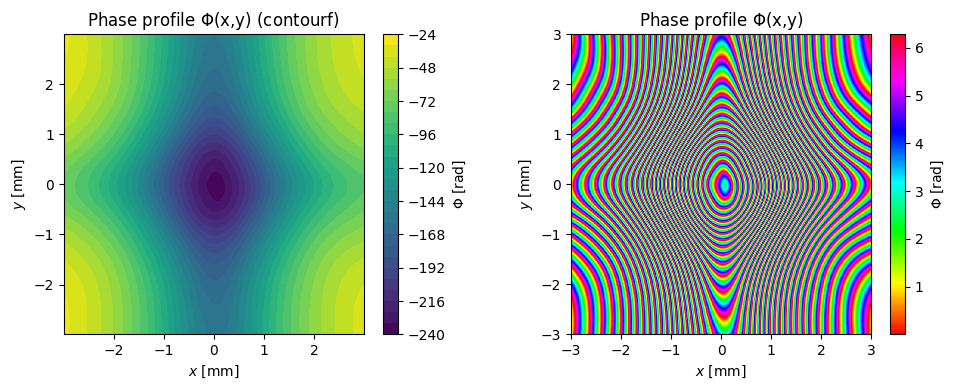

In [10]:
phi_spline = solver.get_phi_spline()


nx, ny = 1000, 1000
x = np.linspace(-solver.M, solver.M, nx)
y = np.linspace(-solver.M, solver.M, ny)
X, Y = np.meshgrid(x, y, indexing='xy')




fig, axs = plt.subplots(1, 2, figsize=(10, 4))
ax1 = axs[0]
im = ax1.contourf(phi_spline(x,y), origin = 'lower',  levels = 30, extent = [x[0]/mm, x[-1]/mm, y[0]/mm, y[-1]/mm])
cb = fig.colorbar(im, orientation = 'vertical',fraction=0.045, label = r'$\Phi$ [rad]')
ax1.set_ylabel("$y$ [mm]")
ax1.set_xlabel('$x$ [mm]')
ax1.set_title(r"Phase profile $\Phi$(x,y) (contourf)")
ax1.set_aspect(1) 

ax2 = axs[1]
im = ax2.imshow((phi_spline(x,y) )  %(np.pi*2), origin = 'lower', cmap = 'hsv', interpolation = 'none', extent = [x[0]/mm, x[-1]/mm, y[0]/mm, y[-1]/mm])
cb = fig.colorbar(im, orientation = 'vertical',fraction=0.045, label = r'$\Phi$ [rad]')
ax2.set_ylabel("$y$ [mm]")
ax2.set_xlabel('$x$ [mm]')
ax2.set_title(r"Phase profile $\Phi$(x,y)")
ax2.set_aspect(1) 

fig.tight_layout()
plt.show()


## Angular-spectrum validation at the target plane

The PINN is trained using a geometrical ray-mapping PDE, so the final phase is validated independently with scalar wave propagation. The input field immediately after the phase mask is

$$
U(x,y)=\sqrt{I(x,y)}\,e^{i\Phi(x,y)},
$$

and it is propagated by the angular-spectrum method over the distance $z$ to the target plane. Agreement between the propagated intensity and the target confirms that the ray-derived phase is also useful in a wave-optics simulation.


### Install/import the propagation package

The following cells use `diffractsim` to perform angular-spectrum propagation. If the package is already installed in your environment, the installation line can be skipped.


In [ ]:
!pip install diffractsim


### Build and propagate the complex field

This cell constructs the phase-modulated field on a high-resolution grid and propagates it by the distance $z$. The original DT-letter setup uses `scale_factor=2`, so the output simulation window expands from 6 mm to 12 mm and contains the 10 mm target region.


In [11]:
import diffractsim

diffractsim.set_backend("CPU")

from diffractsim import MonochromaticField


def I_fun_numpy(x, y):
    r = np.sqrt(x**2 + y**2)
    return np.exp(-(r / w_I)**2)**2


F = MonochromaticField(
    wavelength=λ,
    extent_x=extent_source,
    extent_y=extent_source,
    Nx=2048,
    Ny=2048,
)

F.E = np.sqrt(I_fun_numpy(F.xx, F.yy)) * np.exp(
    1j * phi_spline(F.x, F.y)
)

F.propagate(
    z,
    scale_factor=target_plane_scale_factor,
)


### Compare the propagated intensity with the target

The left panel shows the simulated intensity in the target plane. The right panel compares the central cross section at $y=0$ with the target profile, making the flat-top region and the internal DT-letter structure easier to inspect.


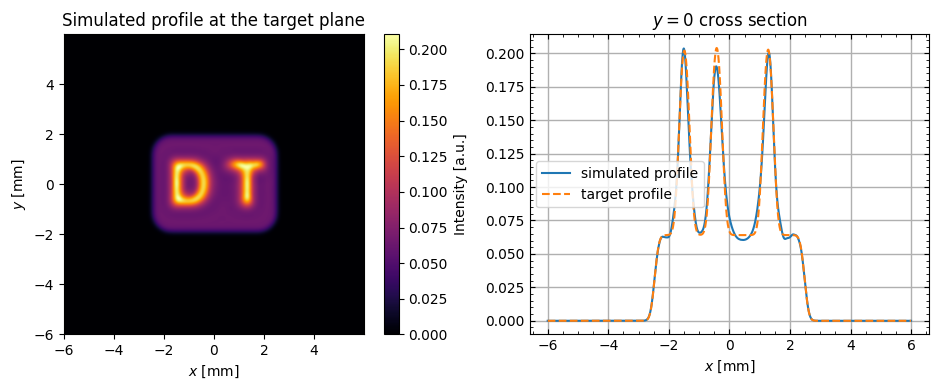

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

ax1 = axs[0]
im = ax1.imshow(
    np.abs(F.E)**2,
    origin="lower",
    cmap="inferno",
    extent=[F.x[0] / mm, F.x[-1] / mm, F.y[0] / mm, F.y[-1] / mm],
    aspect="auto",
)
fig.colorbar(im, ax=ax1, orientation="vertical", fraction=0.045, label="Intensity [a.u.]")
ax1.set_ylabel("$y$ [mm]")
ax1.set_xlabel("$x$ [mm]")
ax1.set_title("Simulated profile at the target plane")
ax1.set_aspect("equal")

ax2 = axs[1]
ax2.tick_params(axis="both", which="both", direction="in", right=True, top=True)
ax2.minorticks_on()
ax2.grid(which="major", linestyle="-", linewidth=1.0)
ax2.plot(
    F.x / mm,
    np.abs(F.E)[F.Ny // 2, :]**2,
    label="simulated profile",
)

network_device = next(solver.net.parameters()).device
x_torch = torch.from_numpy(np.asarray(F.x, dtype="float32")).to(network_device)
target_profile = (
    solver.E_fun_norm(x_torch, x_torch * 0)
    .detach()
    .cpu()
    .numpy()
    .ravel()
)
ax2.plot(
    F.x / mm,
    target_profile,
    "--",
    label="target profile",
)

ax2.set_title("$y=0$ cross section")
ax2.set_xlabel("$x$ [mm]")
ax2.legend()

fig.tight_layout()
plt.show()
